In [ ]:
EXPERIMENT 2

In [ ]:
Scenario 1:Linear Regression-This scenario uses Linear Regression to predict ocean water temperature based on depth, salinity, oxygen, and geographical features and the
                             model performance is evaluated and improved using feature scaling and regularization techniques.

Dataset:https://www.kaggle.com/datasets/sohier/calcofi


K.Nivedha(24BAD082)

EXPERIMENT 2

SCENARIO 1: Linear Regression - Ocean Temperature Prediction

MSE: 6.266115569116484
RMSE: 2.5032210388051
R2 Score: 0.6469070207402909


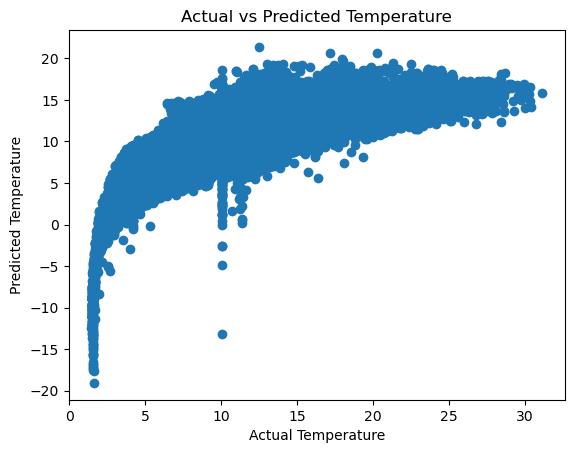

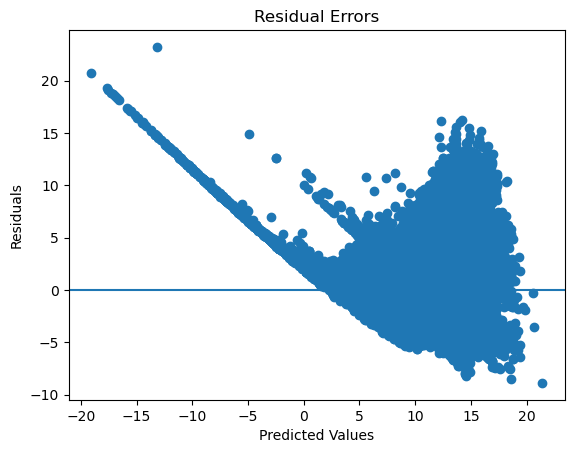

Ridge R2 Score: 0.6469070213032122
Lasso R2 Score: 0.6468551672433376


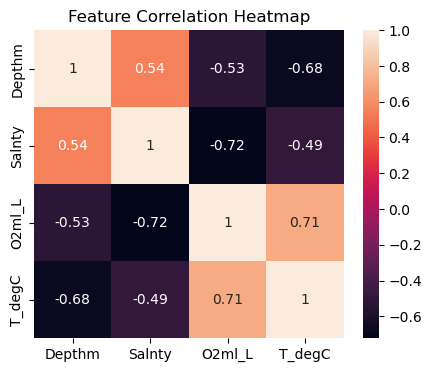

In [1]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 2")
print("\nSCENARIO 1: Linear Regression - Ocean Temperature Prediction\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Load dataset
df = pd.read_csv(r"C:\Users\nived\OneDrive\Documents\bottle.csv", low_memory=False)

# Define available features and target
features = ['Depthm', 'Salnty', 'O2ml_L']
target = 'T_degC'

# Select required data
data = df[features + [target]]

# Handle missing values
data = data.fillna(data.median(numeric_only=True))

# Split features and target
X = data[features]
y = data[target]

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Actual vs Predicted plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Temperature")
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Errors")
plt.show()

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("Ridge R2 Score:", r2_score(y_test, ridge_pred))

# Lasso Regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
print("Lasso R2 Score:", r2_score(y_test, lasso_pred))

plt.figure(figsize=(5,4))
sns.heatmap(data.corr(), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()



In [ ]:
Scenario 2:Logistic Regression-This scenario applies Logistic Regression to classify LIC stock price movement as an increase or decrease using historical trading features and the 
                               model is evaluated using classification metrics and optimized through feature scaling and hyperparameter tuning

Dataset:https://www.kaggle.com/datasets/debashis74017/lic-stock-price-data


K.Nivedha(24BAD082)

EXPERIMENT 2

SCENARIO 2: Logistic Regression - LIC Stock Price Movement Prediction

Accuracy: 0.6132971506105834
Precision: 1.0
Recall: 0.030612244897959183
F1 Score: 0.0594059405940594
Confusion Matrix:
 [[443   0]
 [285   9]]


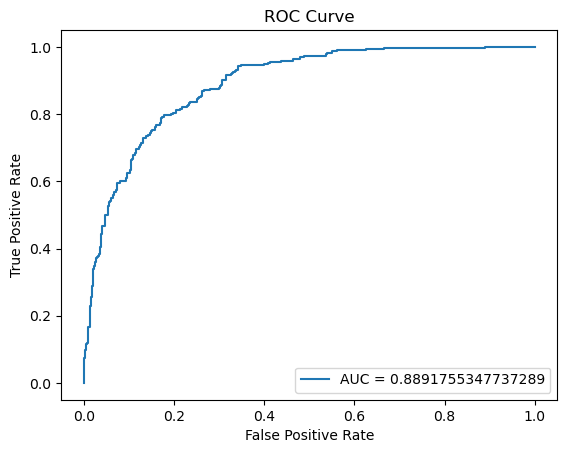

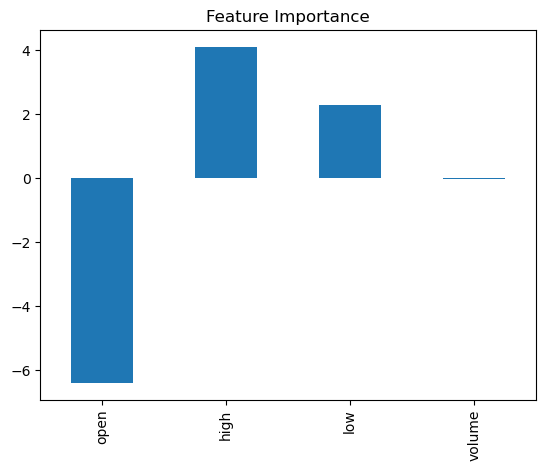

Tuned Model Accuracy: 0.6051560379918589


In [2]:
print("\nK.Nivedha(24BAD082)")
print("\nEXPERIMENT 2")
print("\nSCENARIO 2: Logistic Regression - LIC Stock Price Movement Prediction\n")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc

# Load dataset
df = pd.read_csv(r"C:\Users\nived\OneDrive\Desktop\ML LAB\LICI - 10 minute data.csv")

# Create target variable
df['Price_Movement'] = np.where(df['close'] > df['open'], 1, 0)

# Select features and target
X = df[['open', 'high', 'low', 'volume']]
y = df['Price_Movement']

# Handle missing values
X = X.fillna(X.median())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Feature Importance
importance = pd.Series(model.coef_[0], index=X.columns)
importance.plot(kind='bar', title='Feature Importance')
plt.show()

# Hyperparameter tuning with regularization
tuned_model = LogisticRegression(C=0.5, penalty='l2')
tuned_model.fit(X_train, y_train)

tuned_pred = tuned_model.predict(X_test)
print("Tuned Model Accuracy:", accuracy_score(y_test, tuned_pred))

